# **Bitcoin OTC trust weighted signed network**

Dataset information

This is who-trusts-whom network of people who trade using Bitcoin on a platform called Bitcoin OTC. Since Bitcoin users are anonymous, there is a need to maintain a record of users' reputation to prevent transactions with fraudulent and risky users. Members of Bitcoin OTC rate other members in a scale of -10 (total distrust) to +10 (total trust) in steps of 1. This is the first explicit weighted signed directed network available for research.

# **Exploratory Data Analysis**

In [ ]:
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain
# Load the dataset
df = pd.read_csv('/content/soc-sign-bitcoinotc.csv', names=['source', 'target', 'rating', 'timestamp'])

# Display the first few rows
print(df.head())

   source  target  rating   timestamp
0       6       2       4  1289241912
1       6       5       2  1289241942
2       1      15       1  1289243140
3       4       3       7  1289245277
4      13      16       8  1289254254


In [ ]:
# Convert TIME to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

print(df.head())

   source  target  rating           timestamp
0       6       2       4 2010-11-08 18:45:12
1       6       5       2 2010-11-08 18:45:42
2       1      15       1 2010-11-08 19:05:40
3       4       3       7 2010-11-08 19:41:17
4      13      16       8 2010-11-08 22:10:54


In [ ]:
# Check for missing values
print(df.isnull().sum())

source       0
target       0
rating       0
timestamp    0
dtype: int64


In [ ]:
# Summary statistics for rating
print(df['rating'].describe())

count    35592.000000
mean         1.012025
std          3.562094
min        -10.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: rating, dtype: float64


In [ ]:
# Count of positive and negative ratings
print("Positive Ratings (RATING > 0):", (df['rating'] > 0).sum())
print("Negative Ratings (RATING <= 0):", (df['rating'] <= 0).sum())


Positive Ratings (RATING > 0): 32029
Negative Ratings (RATING <= 0): 3563


In [ ]:
# Number of unique SOURCE and TARGET users
print("Unique source users:", df['source'].nunique())
print("Unique target users:", df['target'].nunique())

Unique source users: 4814
Unique target users: 5858


# **Network Graph**

In [ ]:
import networkx as nx # Import the networkx library and give it the alias 'nx'

#creating a network graph
G = nx.DiGraph()
for _, row in df.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["rating"])

print("\nGraph Created:")
# Basic network properties
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")



Graph Created:
Nodes: 5881
Edges: 35592


# **RESEARCH QUESTIONS**


1.    Do users who joined the network earlier (first 10%) receive higher trust scores than latecomers, and does this advantage persist over time?

2.   Which users exhibit the highest fluctuations in trust over time?

3. Are there users bridging distrustful communities, and do they accelerate distrust propagation?
4. How does the volume of trust ratings change over time?
5. Do the top 20 most trusted users form a tightly interconnected core, and does this concentration of trust create systemic vulnerabilities in the network?
6. How does the overall trust distribution (positive vs. negative) impact the credibility of the network?








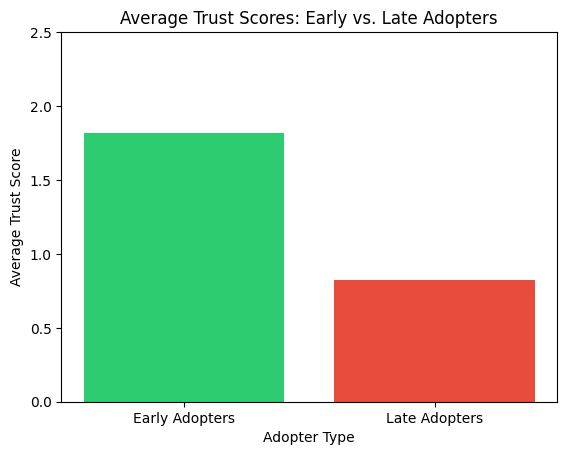

In [ ]:
# Q1 Do users who joined the network earlier (first 10%) receive higher trust scores than latecomers, and does this advantage persist over time?



# Find each user's first appearance (join time) by grouping by target and taking the minimum timestamp
first_appearance = df.groupby('target')['timestamp'].min().reset_index()

# Sort users by join time
first_appearance = first_appearance.sort_values(by='timestamp')

# Calculate the number of early adopters (first 10%)
num_early_adopters = int(0.1 * len(first_appearance))

# Label users as 'early' or 'late' based on their position in the sorted list
first_appearance['adopter_type'] = [
    'early' if i < num_early_adopters else 'late'
    for i in range(len(first_appearance))
]

# Merge adopter type back into the main dataframe
df = df.merge(first_appearance[['target', 'adopter_type']], on='target', how='left')

# Calculate average trust scores for each group
trust_scores = df.groupby('adopter_type')['rating'].mean()

# Visualize the results with a bar chart
plt.bar(['Early Adopters', 'Late Adopters'], trust_scores, color=['#2ecc71', '#e74c3c'])
plt.title('Average Trust Scores: Early vs. Late Adopters')
plt.xlabel('Adopter Type')
plt.ylabel('Average Trust Score')
plt.ylim(0, 2.5)
plt.show()

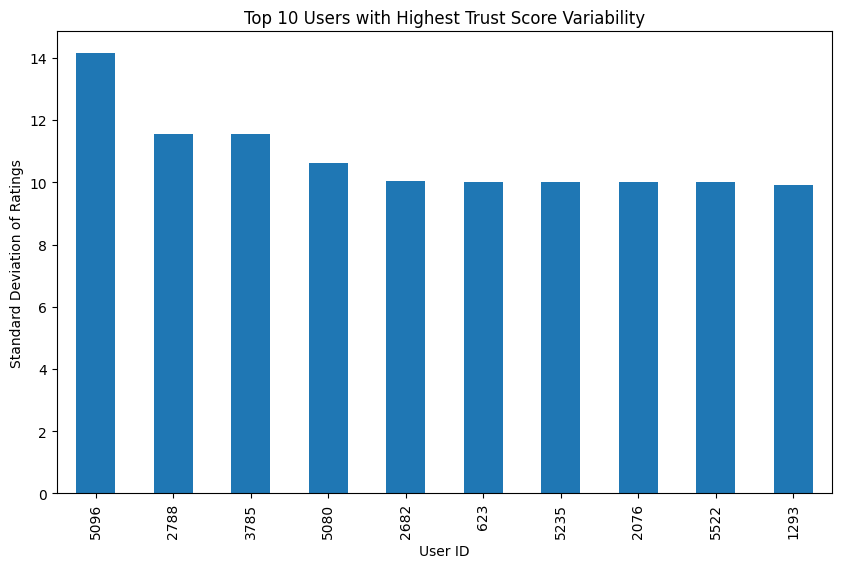

source
5096    14.142136
2788    11.547005
3785    11.547005
5080    10.606602
2682    10.028369
623     10.016653
5235    10.016653
2076    10.016653
5522    10.016653
1293     9.899495
Name: rating, dtype: float64


In [ ]:
#Q2 Which users exhibit the highest fluctuations in trust over time?

# Calculate the standard deviation of ratings per user (source) to measure trust fluctuations
user_trust_changes = df.groupby('source')['rating'].std().sort_values(ascending=False)

# Select the top 10 users with highest variability
top_10 = user_trust_changes.head(10)

# Plot the results in a bar chart
top_10.plot.bar(figsize=(10, 6))
plt.title('Top 10 Users with Highest Trust Score Variability')
plt.xlabel('User ID')
plt.ylabel('Standard Deviation of Ratings')
plt.show()

# Print the top 10 for reference
print(top_10)

Code Explanation

To measure trust fluctuations, we calculate the standard deviation of ratings given by each user (source), as this reflects variability in their trust assignments. We sort these values, select the top 10 users with the highest variability, and visualize them in a bar chart. This pinpoints users whose trust behavior is most inconsistent, addressing the question directly.






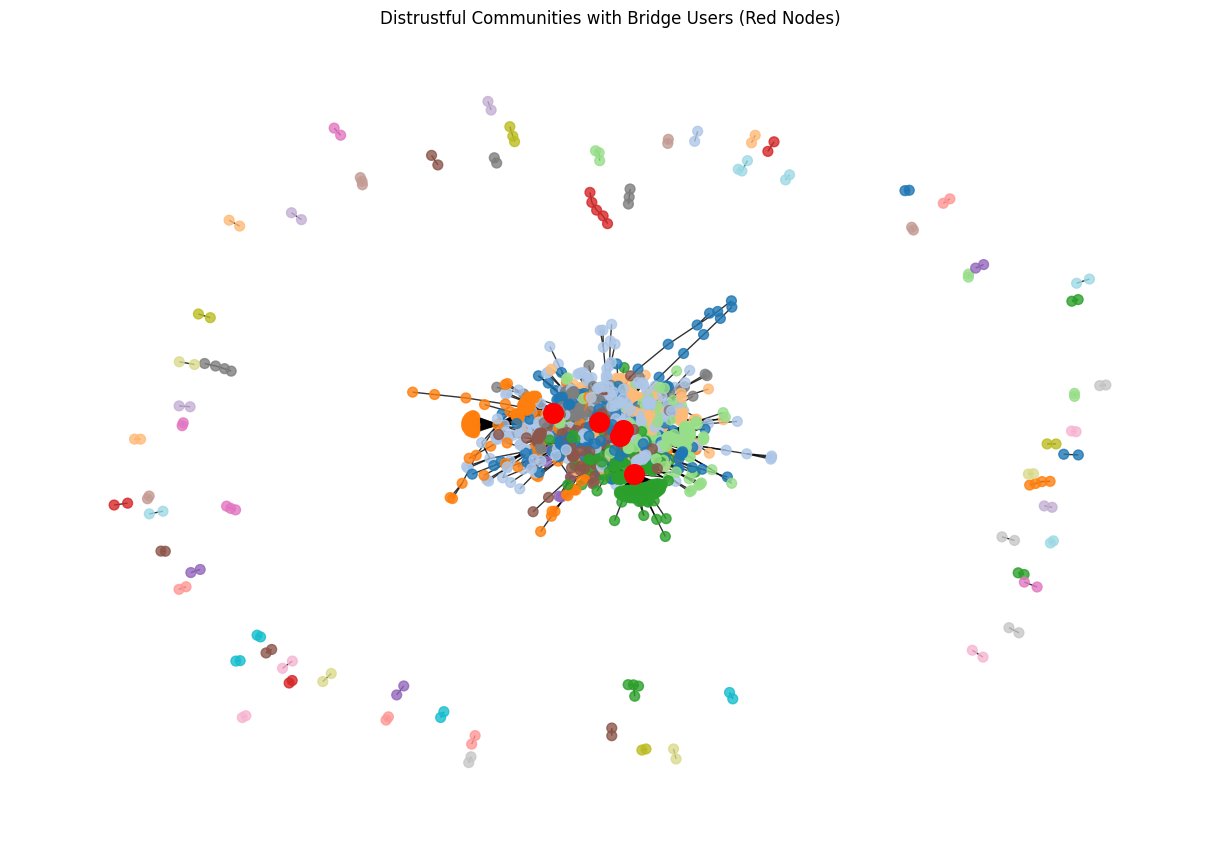

In [ ]:
#Q3 Are there users bridging distrustful communities, and do they accelerate distrust propagation?


# Filter for distrustful edges (negative ratings)
distrust_edges = df[df['rating'] < 0][['source', 'target']]

# Build an undirected graph of distrust relationships
G_distrust = nx.from_pandas_edgelist(distrust_edges, 'source', 'target', create_using=nx.Graph())

# Detect communities using the Louvain algorithm
partition = community_louvain.best_partition(G_distrust)

# Calculate betweenness centrality to identify bridge users
betweenness = nx.betweenness_centrality(G_distrust)
bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

# Visualize the network
pos = nx.spring_layout(G_distrust)
colors = [partition[node] for node in G_distrust.nodes()]
plt.figure(figsize=(12, 8))
nx.draw(G_distrust, pos, node_color=colors, node_size=50, alpha=0.8, cmap=plt.cm.tab20)
nx.draw_networkx_nodes(G_distrust, pos, nodelist=[u[0] for u in bridges], node_size=200, node_color='red')
plt.title('Distrustful Communities with Bridge Users (Red Nodes)')
plt.show()

Code Explanation:

This code isolates distrustful interactions by filtering for negative ratings. It then builds a graph where each node is a user and each edge represents a distrustful relationship. The Louvain algorithm groups users into communities based on their interactions. Betweenness centrality is calculated to find key nodes users who frequently lie on the shortest paths between other nodes indicating that they connect separate communities.

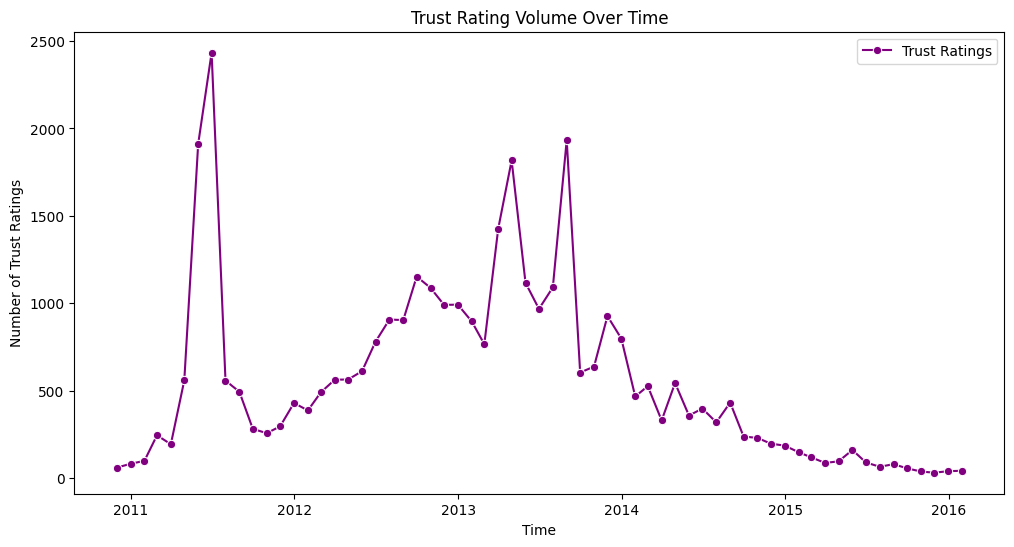

In [ ]:
#Q4  How does the volume of trust ratings change over time


# Resample by month to count ratings
trust_volume = df.resample('ME', on='timestamp').size()

# Plot the volume over time
plt.figure(figsize=(12, 6))
sns.lineplot(x=trust_volume.index, y=trust_volume.values, marker='o', color='purple', label='Trust Ratings')
plt.xlabel('Time')
plt.ylabel('Number of Trust Ratings')
plt.title('Trust Rating Volume Over Time')
plt.legend()
plt.show()

CODE EXPLANATION:

We first resample our trust ratings data by month-end using the 'timestamp' column. This groups the ratings into monthly buckets and counts the total ratings per month. This step smooths out daily fluctuations and highlights overall trends in trust rating activity.


Connections Among Top 20 Trusted Users: 219 edges


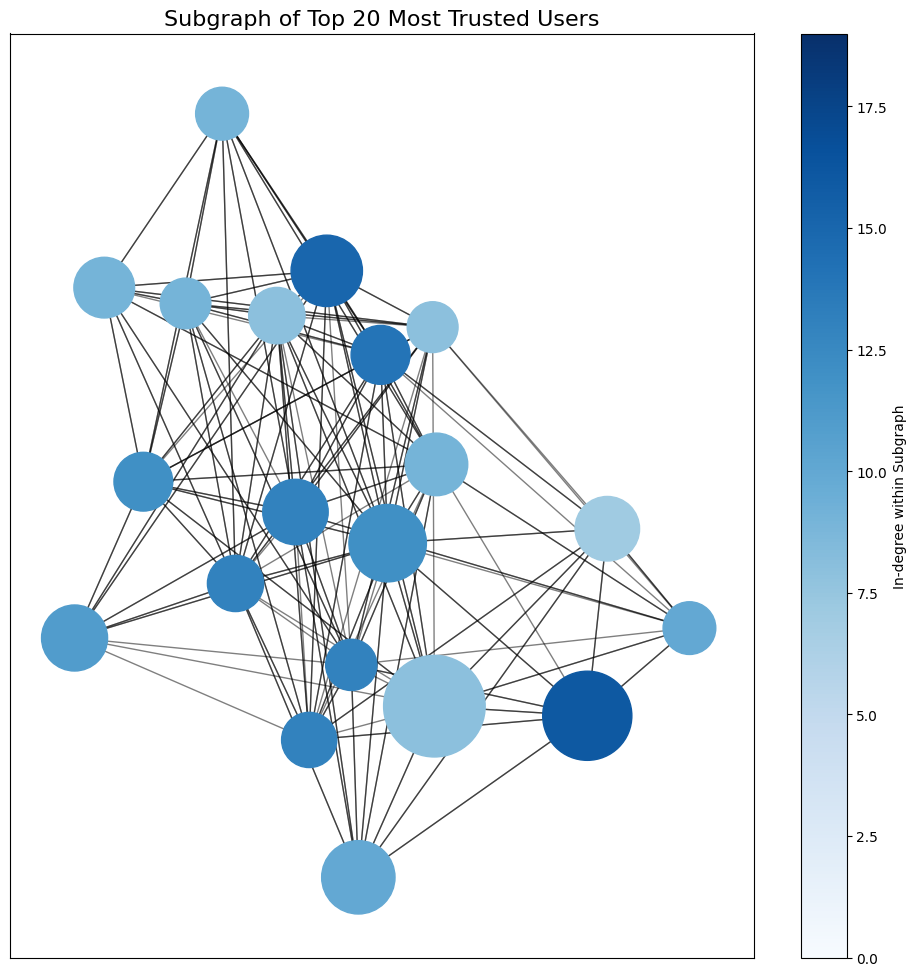

In [ ]:
#Q5 Do the top 20 most trusted users form a tightly interconnected core, and does this concentration of trust create systemic vulnerabilities in the network?
# Calculate in-degree for each node (number of users trusting each user)
in_degree = G.in_degree()

# Sort users by in-degree in descending order to get the most trusted users
sorted_in_degree = sorted(in_degree, key=lambda x: x[1], reverse=True)

# Get the top 20 users
top_users = [user for user, _ in sorted_in_degree[:20]]

# Create a subgraph with these top users
subgraph = G.subgraph(top_users)

# Print the number of edges in the subgraph
print(f"\nConnections Among Top 20 Trusted Users: {subgraph.number_of_edges()} edges")
# Compute in-degrees within the subgraph for coloring
subgraph_in_degree = dict(subgraph.in_degree())

# Get overall in-degrees for node sizes
overall_in_degrees = [in_degree[user] for user in top_users]
node_sizes = [deg * 10 for deg in overall_in_degrees]  # Scale factor for visibility

# Get subgraph in-degrees for coloring
subgraph_in_degrees = [subgraph_in_degree[user] for user in top_users]

# Set up the plot
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(subgraph, k=1.5, iterations=50)  # Layout for clarity

# Draw nodes with sizes and colors
sc = nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color=subgraph_in_degrees,
                            cmap='Blues', vmin=0, vmax=19)

# Draw directed edges with arrows
nx.draw_networkx_edges(subgraph, pos, arrows=True, arrowsize=10, alpha=0.5)

# Add a colorbar to explain node colors
plt.colorbar(sc, label='In-degree within Subgraph')

# Add a title and display the plot
plt.title('Subgraph of Top 20 Most Trusted Users', fontsize=16)
plt.show()

Code Explanation:

We calculate the in-degree (incoming trust) of each user to rank them by how many trust ratings they receive. Then, we extract the top 20 most trusted users and create a subgraph of their interactions. In this subgraph, the size of each node reflects the user's overall in-degree from the full network, while the color of each node represents the in-degree within the subgroup. The edges indicate trust relationships among these users. This visualization helps us assess how tightly interconnected the top trusted users are and whether their dense connectivity could create systemic risk for the network.

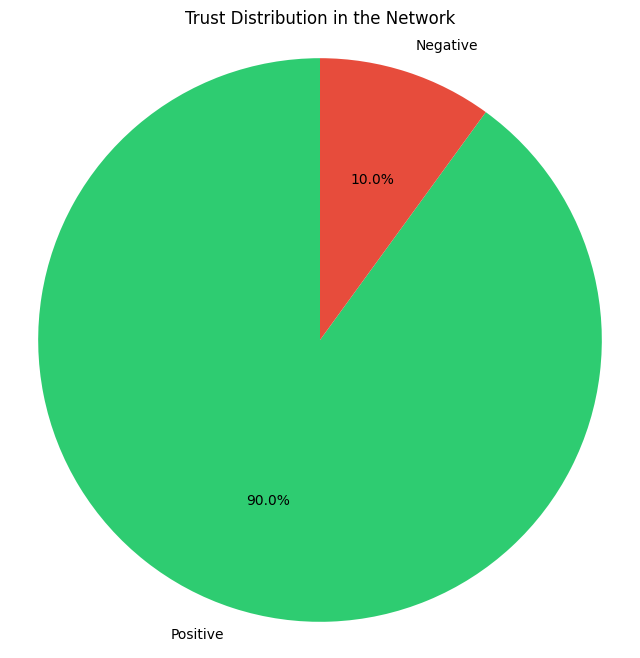

In [ ]:
#Q6 How does the overall trust distribution (positive vs. negative) impact the credibility of the network

# Count positive and negative ratings
positive = df[df['rating'] > 0].shape[0]
negative = df[df['rating'] < 0].shape[0]

# Plot as a pie chart
labels = ['Positive', 'Negative']
sizes = [positive, negative]
colors = ['#2ecc71', '#e74c3c']
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Trust Distribution in the Network')
plt.axis('equal')
plt.show()

Code Explanation

We count positive and negative ratings and plot their proportions in a pie chart. This simple visualization shows the trust-distrust balance, directly addressing the question of distribution and its implications for credibility.



In [ ]:
def colab2pdf():
  # @title Download Notebook in PDF Format{display-mode:'form'}
  !apt-get install -yqq --no-install-recommends librsvg2-bin>/dev/null;
  import contextlib,datetime,google,io,IPython,ipywidgets,json,locale,nbformat,os,pathlib,requests,urllib,warnings,werkzeug,yaml,re;locale.setlocale(locale.LC_ALL,'en_US.UTF-8');warnings.filterwarnings('ignore',category=nbformat.validator.MissingIDFieldWarning);
  %matplotlib inline
  def convert(b):
    try:
      s.value='🔄 Converting';b.disabled=True
      n=pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(requests.get(f'http://{os.environ["COLAB_JUPYTER_IP"]}:{os.environ["KMP_TARGET_PORT"]}/api/sessions').json()[0]['name'])))
      p=pathlib.Path('/content/pdfs')/f'{datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")}_{n.stem}';p.mkdir(parents=True,exist_ok=True);nb=nbformat.reads(json.dumps(google.colab._message.blocking_request('get_ipynb',timeout_sec=600)['ipynb']),as_version=4)
      u=[u for c in nb.cells if c.get('cell_type')=='markdown' for u in re.findall(r'!\[.?\]\((https?://.?)\)',c['source']) if requests.head(u,timeout=5).status_code!=200]
      if u:raise Exception(f"Bad Image URLs: {','.join(u)}")
      nb.cells=[cell for cell in nb.cells if '--Colab2PDF' not in cell.source]
      nb=nbformat.v4.new_notebook(cells=nb.cells or [nbformat.v4.new_code_cell('#')]);nbformat.validator.normalize(nb)
      nbformat.write(nb,(p/f'{n.stem}.ipynb').open('w',encoding='utf-8'))
      with (p/'config.yml').open('w', encoding='utf-8') as f: yaml.dump({'include-in-header':[{'text':r'\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}'}],'include-before-body':[{'text':r'\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}'}]},f)
      !quarto render {p}/{n.stem}.ipynb --metadata-file={p}/config.yml --to pdf -M latex-auto-install -M margin-top=1in -M margin-bottom=1in -M margin-left=1in -M margin-right=1in --quiet
      google.colab.files.download(str(p/f'{n.stem}.pdf'));s.value=f'✅ Downloaded: {n.stem}.pdf'
    except Exception as e:s.value=f'❌ {str(e)}'
    finally:b.disabled=False
  if not pathlib.Path('/usr/local/bin/quarto').exists():
    !wget -q 'https://quarto.org/download/latest/quarto-linux-amd64.deb' && dpkg -i quarto-linux-amd64.deb>/dev/null && quarto install tinytex --update-path --quiet && rm quarto-linux-amd64.deb
  b=ipywidgets.widgets.Button(description='⬇ Download');s=ipywidgets.widgets.Label();b.on_click(lambda b:convert(b));IPython.display.display(ipywidgets.widgets.HBox([b,s]))
colab2pdf() # | Colab2PDF v1.6 | https://github.com/drengskapur/colab2pdf | GPL-3.0-or-later |

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>